In [1]:
#Import models and libraries
from DT.DecisionTree import DecisionTree
from sklearn.tree import DecisionTreeClassifier
from GNB.gaussian_naive_bayes import GNB
from LogisticRegresssion.LogisticRegression import MultiLogReg
from tensorflow import keras
from SVM.linear_svm import LinearSVMScartch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from Kfolds import run_kfold
import itertools
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from diagnosis_curves import analysis_curves



c:\Users\Moaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Moaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Moaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/

In [3]:
#Download Data
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()


In [4]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
import numpy as np
from skimage.feature import hog

def extract_hog_features(X):
    features = []

    for img in X:
        img_2d = img.reshape(28, 28)

        hog_features = hog(
            img_2d,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True
        )

        features.append(hog_features)

    return np.array(features)

In [6]:
X_train_HOG = extract_hog_features(X_train)
X_test_HOG = extract_hog_features(X_test)

In [7]:
pca = PCA(n_components=50)  

X_train_hog_pca = pca.fit_transform(X_train_HOG)
X_test_hog_pca = pca.transform(X_test_HOG)

In [7]:
print(X_test_hog_pca.shape)

(10000, 50)


In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_hog_pca, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [12]:
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(48000, 50) (12000, 50) (48000,) (12000,)


In [9]:


def manual_grid_search_DT(X, y, param_grid, k=3):

    keys = list(param_grid.keys())
    values = list(param_grid.values())

    best_score = -1
    best_params = None
    results = []

    for combo in itertools.product(*values):

        params = dict(zip(keys, combo))

        print("\nTesting:", params)

        kf = KFold(n_splits=k, shuffle=True, random_state=42)

        fold_scores = []

        for train_idx, val_idx in kf.split(X):

            X_train_fold = X[train_idx]
            X_val_fold = X[val_idx]

            y_train_fold = y[train_idx]
            y_val_fold = y[val_idx]

            model = DecisionTree(
                maxDepth=params["maxDepth"],
                minSamplesSplit=params["minSamplesSplit"],
                minSampleLeafs=params["minSampleLeafs"],
                criterion=params["criterion"],
                maxFeatures=params["maxFeatures"]
            )

            model.fit(X_train_fold, y_train_fold)

            preds = model.predict(X_val_fold)

            score = f1_score(y_val_fold, preds, average="macro")

            fold_scores.append(score)

        avg_score = sum(fold_scores) / len(fold_scores)

        print("Average score:", avg_score)

        results.append((params, avg_score))

        if avg_score > best_score:
            best_score = avg_score
            best_params = params

    print("\nBest params:", best_params)
    print("Best score:", best_score)

    return best_params, best_score, results

In [10]:
#DT hyper parameter tuning
param_grid = {
    "maxDepth": [8, 12, 15],
    "minSamplesSplit": [5, 10, 20],
    "minSampleLeafs": [1, 5, 10],
    "criterion": ["gini", "entropy"],
    "maxFeatures": ["sqrt", "log2"]
}
best_params, _, _ = manual_grid_search_DT(X_train , y_train , param_grid)




Testing: {'maxDepth': 8, 'minSamplesSplit': 5, 'minSampleLeafs': 1, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.6533398346235456

Testing: {'maxDepth': 8, 'minSamplesSplit': 5, 'minSampleLeafs': 1, 'criterion': 'gini', 'maxFeatures': 'log2'}
Average score: 0.6083085570726462

Testing: {'maxDepth': 8, 'minSamplesSplit': 5, 'minSampleLeafs': 1, 'criterion': 'entropy', 'maxFeatures': 'sqrt'}
Average score: 0.7252232631103747

Testing: {'maxDepth': 8, 'minSamplesSplit': 5, 'minSampleLeafs': 1, 'criterion': 'entropy', 'maxFeatures': 'log2'}
Average score: 0.6746986135964438

Testing: {'maxDepth': 8, 'minSamplesSplit': 5, 'minSampleLeafs': 5, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.6860648766621428

Testing: {'maxDepth': 8, 'minSamplesSplit': 5, 'minSampleLeafs': 5, 'criterion': 'gini', 'maxFeatures': 'log2'}
Average score: 0.628255587300742

Testing: {'maxDepth': 8, 'minSamplesSplit': 5, 'minSampleLeafs': 5, 'criterion': 'entropy', 'maxFeatures': 'sqrt

In [16]:
#Decision Tree results
#Best params =>{'maxDepth': 15, 'minSamplesSplit': 20, 'minSampleLeafs': 1, 'criterion': 'entropy', 'maxFeatures': 'sqrt'}
best_params['maxFeatures'] = None
def train_DT(X, y):
    dt = DecisionTree(**best_params)
    dt.fit(X, y)
    return dt
def predict_DT(model, X):
    return model.predict(X)

#Validation
print("Validation results")
# run_kfold(X_train , y_train , train_DT , predict_DT ,k=3, binary=0)

dt = DecisionTree(**best_params)


dt.fit(X_train , y_train)
predictions = dt.predict(X_test_hog_pca)
print(classification_report(
    y_test, predictions,
))



Validation results
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       980
           1       0.96      0.97      0.96      1135
           2       0.88      0.91      0.90      1032
           3       0.82      0.86      0.84      1010
           4       0.90      0.89      0.90       982
           5       0.87      0.85      0.86       892
           6       0.95      0.94      0.95       958
           7       0.90      0.88      0.89      1028
           8       0.81      0.77      0.79       974
           9       0.85      0.87      0.86      1009

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [12]:


# Train
gnb = GNB()
gnb.gaussian_naive_train(X_train, y_train)

# Tune weights
best_weight = None
best_score = -1

def train_gnb(X, y):
    gnb = GNB()
    gnb.gaussian_naive_train(X, y)
    return gnb


def predict_gnb(model, X):
    return model.predict(
        X)



print("\n=== K-FOLD VALIDATION ===")
run_kfold(X_train, y_train, train_gnb, predict_gnb, k=5 , binary=0)



gnb = GNB()
gnb.gaussian_naive_train(X_train, y_train)

predictions = gnb.predict(
    X_test_hog_pca, 
)

print(classification_report(
    y_test,
    predictions,
))


=== K-FOLD VALIDATION ===
Fold 1 → F1: 0.9288
Fold 2 → F1: 0.9320
Fold 3 → F1: 0.9311
Fold 4 → F1: 0.9326
Fold 5 → F1: 0.9349

K-Fold Avg F1: 0.93188790621865
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       980
           1       0.99      0.96      0.97      1135
           2       0.94      0.94      0.94      1032
           3       0.93      0.95      0.94      1010
           4       0.95      0.95      0.95       982
           5       0.95      0.93      0.94       892
           6       0.98      0.94      0.96       958
           7       0.96      0.89      0.92      1028
           8       0.85      0.93      0.89       974
           9       0.90      0.92      0.91      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



Starting Learning Curve evaluations...

--- Running Evaluation 1/2: ACCURACY ---
Size 20/48000 -> Train: 1.0000 | Val: 0.5843
Size 6874/48000 -> Train: 0.9041 | Val: 0.9009
Size 13728/48000 -> Train: 0.9053 | Val: 0.9028
Size 20582/48000 -> Train: 0.9064 | Val: 0.9032
Size 27437/48000 -> Train: 0.9058 | Val: 0.9018
Size 34291/48000 -> Train: 0.9069 | Val: 0.9038
Size 41145/48000 -> Train: 0.9074 | Val: 0.9054
Size 48000/48000 -> Train: 0.9079 | Val: 0.9048


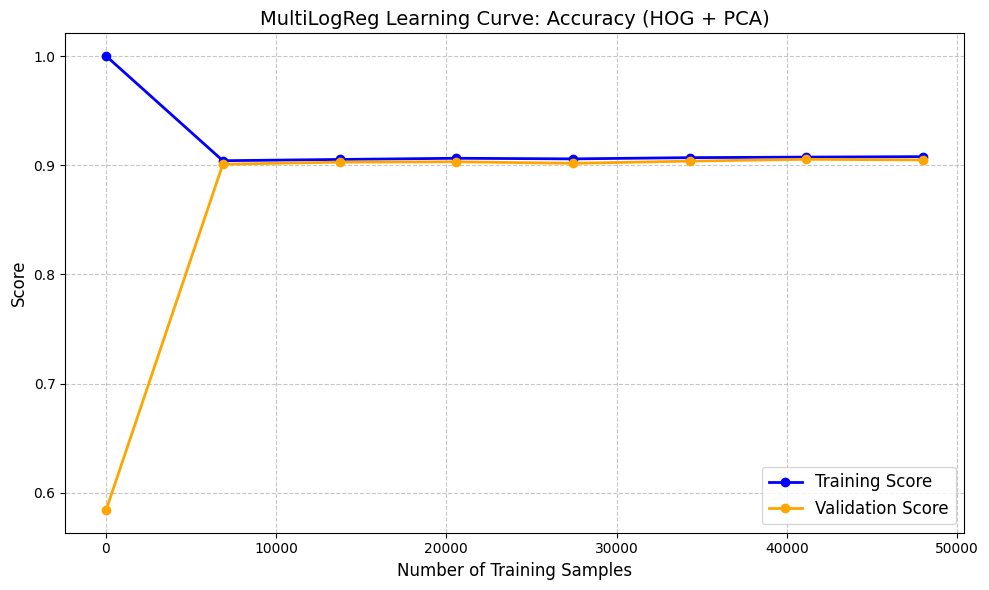


--- Running Evaluation 2/2: MACRO F1-SCORE ---
Size 20/48000 -> Train: 1.0000 | Val: 0.5121
Size 6874/48000 -> Train: 0.9031 | Val: 0.9004
Size 13728/48000 -> Train: 0.9044 | Val: 0.9024
Size 20582/48000 -> Train: 0.9057 | Val: 0.9028
Size 27437/48000 -> Train: 0.9052 | Val: 0.9013
Size 34291/48000 -> Train: 0.9065 | Val: 0.9034
Size 41145/48000 -> Train: 0.9070 | Val: 0.9050
Size 48000/48000 -> Train: 0.9073 | Val: 0.9045


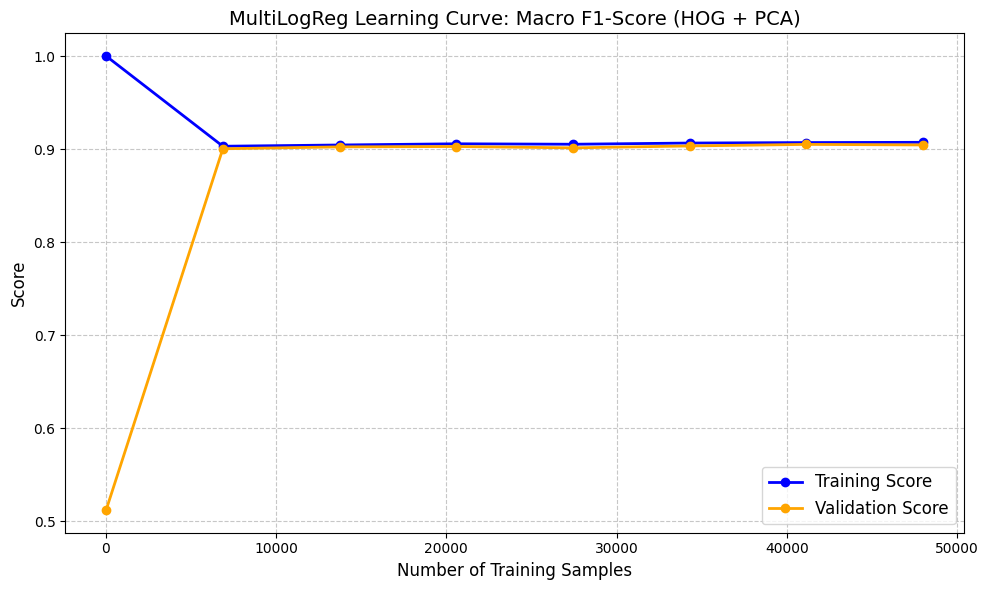

In [13]:
from sklearn.metrics import f1_score, accuracy_score

print("Starting Learning Curve evaluations...\n")
def train_multilogreg(X_subset, y_subset):
    model = MultiLogReg(
        max_iterations=100, 
        learning_rate=0.1, 
        reg_eqn='L2',       
        reg_param=0.1,      
        random_state=42
    )
    model.fit(X_subset, y_subset)
    return model

def predict_multilogreg(model, X):
    return model.predict(X)

def metric_acc(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def metric_f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')


print("--- Running Evaluation 1/2: ACCURACY ---")
subset_sizes_acc, train_trends_acc, val_trends_acc = analysis_curves(
    X_train=X_train, 
    y_train=y_train, 
    X_val=X_val, 
    y_val=y_val, 
    train_fn=train_multilogreg, 
    predict_fn=predict_multilogreg, 
    metric_fn=metric_acc, 
    num_steps=8,
    title="MultiLogReg Learning Curve: Accuracy (HOG + PCA)"
)


print("\n--- Running Evaluation 2/2: MACRO F1-SCORE ---")
subset_sizes_f1, train_trends_f1, val_trends_f1 = analysis_curves(
    X_train=X_train, 
    y_train=y_train, 
    X_val=X_val, 
    y_val=y_val, 
    train_fn=train_multilogreg, 
    predict_fn=predict_multilogreg, 
    metric_fn=metric_f1_macro, 
    num_steps=8,
    title="MultiLogReg Learning Curve: Macro F1-Score (HOG + PCA)"
)

In [8]:
import itertools
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from GridSearches import gridSearchLog


# 1. Comprehensive Hyperparameter Grid
# Covers iterations up to 1000 and includes L1/L2 regularization as requested
param_grid = {
    'max_iterations': [100, 500, 1000, 1500],       # Checks for deep convergence
    'learning_rate': [0.001, 0.01, 0.1, 0.5], # Adds a safety low-rate
    'class_weight': [None, 'balanced'],
    'reg_eqn': [None, 'L1', 'L2'],
    'reg_param': [0.001, 0.01, 0.1, 1.0, 10.0], # Wider range of penalties
    'random_state': [42]
}

# 2. Define the 4 Preprocessing Configurations using your provided variables
# We flatten the raw X_train for the model
X_train_raw = X_train.reshape(X_train.shape[0], -1)

# Generate PCA Only (50) for the full raw dataset
pca_raw = PCA(n_components=50, random_state=42)
X_train_pca_only = pca_raw.fit_transform(X_train_raw)

configs = {
    "Raw Pixels": X_train_raw,
    "PCA Only (50)": X_train_pca_only,
    "HOG Only": X_train_HOG,        
    "HOG + PCA (50)": X_train_hog_pca # Using your HOG+PCA variable
}

# 3. Execution Loop
final_comparison = {}

for name, data in configs.items():
    print(f"\n" + "="*60)
    print(f"STARTING FULL DATA GRID SEARCH: {name}")
    print(f"Feature Dimensions: {data.shape[1]}")
    print("="*60)
    
    # Calls your custom gridSearchLog function on the full y_train (60,000 samples)
    best_params, best_score, _ = gridSearchLog(
        x=data, 
        y=y_train, 
        param_grid=param_grid, 
        k_cross=3
    )
    
    final_comparison[name] = {
        "best_score": best_score,
        "best_params": best_params
    }

# 4. Final Performance Report
print("\n" + "#"*60)
print("FINAL PREPROCESSING PERFORMANCE SUMMARY (PHASE 2)")
print("#"*60)
for name, results in final_comparison.items():
    print(f"{name:15} | Best Macro F1: {results['best_score']:.4f}")
    print(f"Optimal Params: {results['best_params']}")
    print("-" * 30)


STARTING FULL DATA GRID SEARCH: Raw Pixels
Feature Dimensions: 784
Average f1-score of {'max_iterations': 100, 'learning_rate': 0.001, 'class_weight': None, 'reg_eqn': None, 'reg_param': 0.001, 'random_state': 42}: 0.23209568599337702
Average f1-score of {'max_iterations': 100, 'learning_rate': 0.001, 'class_weight': None, 'reg_eqn': None, 'reg_param': 0.01, 'random_state': 42}: 0.23209568599337702
Average f1-score of {'max_iterations': 100, 'learning_rate': 0.001, 'class_weight': None, 'reg_eqn': None, 'reg_param': 0.1, 'random_state': 42}: 0.23209568599337702
Average f1-score of {'max_iterations': 100, 'learning_rate': 0.001, 'class_weight': None, 'reg_eqn': None, 'reg_param': 1.0, 'random_state': 42}: 0.23209568599337702
Average f1-score of {'max_iterations': 100, 'learning_rate': 0.001, 'class_weight': None, 'reg_eqn': None, 'reg_param': 10.0, 'random_state': 42}: 0.23209568599337702
Average f1-score of {'max_iterations': 100, 'learning_rate': 0.001, 'class_weight': None, 'reg_eqn

KeyboardInterrupt: 